In [1]:
import warnings
warnings.filterwarnings("ignore")
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_csv("gym_membership_dataset.csv")
df

,member_id,age,membership_type,monthly_fee,visits_per_month,weight_kg
0,1,43,basic,20,25,66.5
1,2,32,premium,70,11,114.9
2,3,41,basic,20,3,115.2
3,4,25,premium,70,13,61.7
4,5,55,standard,40,15,80.9
...,...,...,...,...,...,...
1510,1114,37,premium,70,6,94.7
1511,1018,29,premium,70,7,63.3
1512,470,27,basic,20,3,58.0
1513,1481,45,basic,20,20,109.6


In [2]:
df.shape

(1515, 6)

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1515 entries, 0 to 1514
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   member_id         1515 non-null   int64  
 1   age               1515 non-null   int64  
 2   membership_type   1515 non-null   str    
 3   monthly_fee       1515 non-null   int64  
 4   visits_per_month  1515 non-null   int64  
 5   weight_kg         1459 non-null   float64
dtypes: float64(1), int64(4), str(1)
memory usage: 80.9 KB


In [4]:
df.describe()

,member_id,age,monthly_fee,visits_per_month,weight_kg
count,1515.000000,1515.000000,1515.000000,1515.000000,1459.000000
mean,751.741254,40.234983,37.755776,15.144554,81.795408
std,432.870216,14.243178,18.033611,10.492664,21.675736
min,1.000000,16.000000,20.000000,0.000000,45.000000
25%,378.500000,28.000000,20.000000,7.000000,62.900000
50%,751.000000,41.000000,40.000000,15.000000,82.100000
75%,1125.500000,53.000000,40.000000,22.000000,100.900000
max,1500.000000,64.000000,70.000000,112.000000,119.900000


In [5]:
df.duplicated().sum()

np.int64(15)

In [6]:
df.isnull().sum()

member_id            0
age                  0
membership_type      0
monthly_fee          0
visits_per_month     0
weight_kg           56
dtype: int64

In [7]:
no_rows = df.shape[0]
null_value_count = df.isnull().sum().to_list()
columns_df = df.columns.to_list()

for column, count in zip(columns_df, null_value_count):
    print(f'null percentage {column}: {count / no_rows * 100:.2f}%')

null percentage member_id: 0.00%
null percentage age: 0.00%
null percentage membership_type: 0.00%
null percentage monthly_fee: 0.00%
null percentage visits_per_month: 0.00%
null percentage weight_kg: 3.70%


In [8]:
# drop the duplicate rows
df=df.drop_duplicates()
df.shape

(1500, 6)

In [9]:
# fill missing weight_kg with the median
weight_kg_median = df['weight_kg'].median()
df['weight_kg'] = df['weight_kg'].fillna(weight_kg_median)

In [10]:
df.isnull().sum()

member_id           0
age                 0
membership_type     0
monthly_fee         0
visits_per_month    0
weight_kg           0
dtype: int64

In [11]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df['membership_type']=le.fit_transform(df['membership_type'])

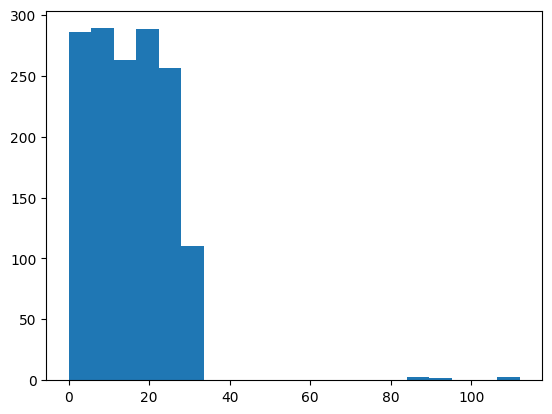

In [12]:
# histogram to see the distribution
plt.hist(x=df['visits_per_month'],bins=20)
plt.show()

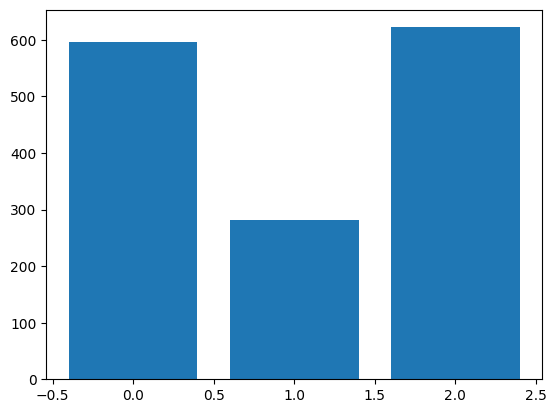

In [13]:
# bar chart
plt.bar(x=df['membership_type'].value_counts().index,height=df['membership_type'].value_counts().values)
plt.show()

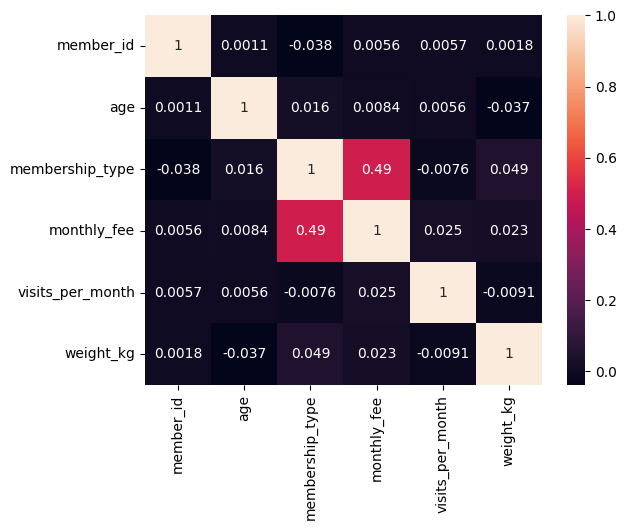

In [14]:
# correlation heatmap
sns.heatmap(df.corr(),annot=True)
plt.show()

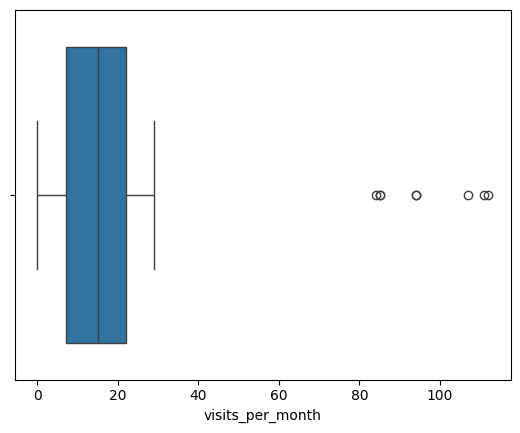

In [15]:
# boxplot to spot outliers in visits_per_month
sns.boxplot(x=df['visits_per_month'])
plt.show()

In [16]:
# identify outliers using the IQR method
Q1 = df['visits_per_month'].quantile(0.25)
Q3 = df['visits_per_month'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = df[(df['visits_per_month'] < lower_bound) | (df['visits_per_month'] > upper_bound)]
outliers

,member_id,age,membership_type,monthly_fee,visits_per_month,weight_kg
166,167,56,1,70,85,66.6
249,250,51,2,40,94,62.2
798,799,38,0,20,111,82.1
861,862,34,1,70,107,90.1
1144,1145,54,2,40,85,64.2
1151,1152,22,0,20,84,82.1
1222,1223,38,2,40,112,104.6
1473,1474,54,0,20,94,67.6


In [17]:
# remove the outliers
df = df[(df['visits_per_month'] >= lower_bound) & (df['visits_per_month'] <= upper_bound)]
df.shape

(1492, 6)